# Домашнее задание "Почувствуй мощь трансформеров в бою"

---



## Задание 1. Файтьюн и тестирование ruBert-base

Установим базовые нужные библиотеки.

In [ ]:
import warnings
warnings.filterwarnings("ignore", category=UserWarning, module="huggingface_hub")

In [ ]:
import torch
import numpy as np
import re
import pandas as pd
from datasets import Dataset

Проверим доступность GPU:

In [ ]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

Using device: cuda


Загрузим тренеровочный датасет:

In [ ]:
all_train_data = pd.read_csv("https://raw.githubusercontent.com/RussianNLP/RuCoLA/refs/heads/main/data/in_domain_train.csv").filter(items=['sentence', 'acceptable']).rename(columns={'acceptable': 'labels'})
all_train_data

,sentence,labels
0,"Вдруг решетка беззвучно поехала в сторону, и н...",1
1,Этим летом не никуда ездили.,0
2,Только Иван выразил какую бы то ни было готовн...,1
3,"Теперь ты видишь собственными глазами, как тут...",1
4,На поверку вся теория оказалась полной чепухой.,1
...,...,...
7864,Установки не было введено в действие.,0
7865,"Конечно, против такой системы ценностей решите...",0
7866,Симптомов болезни не исчезло.,0
7867,Послезавтра температура у больного снижается д...,0


Посмотрим на распределение классов в данных.

In [ ]:
all_train_data['labels'].value_counts()

,count
labels,
1,5864
0,2005


Видно, что в данных большой перекос в сторону корректных предложений. Учтем это при обучении.

Сделаем небольшую валидационную выборку (того же размера, что и тестовая)

In [ ]:
val_dataset = all_train_data.sample(n=983)
train_dataset = pd.concat([all_train_data, val_dataset]).drop_duplicates(keep=False)
train_dataset

,sentence,labels
0,"Вдруг решетка беззвучно поехала в сторону, и н...",1
1,Этим летом не никуда ездили.,0
2,Только Иван выразил какую бы то ни было готовн...,1
4,На поверку вся теория оказалась полной чепухой.,1
5,Он всегда сидит в библиотеке.,1
...,...,...
7863,Вани не было за городом две недели.,0
7865,"Конечно, против такой системы ценностей решите...",0
7866,Симптомов болезни не исчезло.,0
7867,Послезавтра температура у больного снижается д...,0


Наконец, тестовая выборка.

In [ ]:
test_dataset = pd.read_csv("https://raw.githubusercontent.com/RussianNLP/RuCoLA/refs/heads/main/data/in_domain_dev.csv").filter(items=['sentence', 'acceptable']).rename(columns={'acceptable': 'labels'})
test_dataset

,sentence,labels
0,Иван вчера не позвонил.,1
1,"У многих туристов, кто посещают Кемер весной, ...",0
2,Лесные запахи набегали волнами; в них смешалос...,1
3,Вчера президент имел неофициальную беседу с ан...,1
4,Коллега так и не признал вину за катастрофу пе...,1
...,...,...
978,Мысли отказываются остановиться на всяком пред...,0
979,"Не должно быть подозрений, что судью привлекаю...",0
980,"Хорошо, что он купил что-нибудь.",0
981,"Если бы я не потерял очков, не пришлось бы пок...",0


Проанализируем, сколько в среднем и максимально может быть слов в предложениях тренировочного и тестового корпусов. Для этого подойдут гистограммы:

In [ ]:
import matplotlib.pyplot as plt

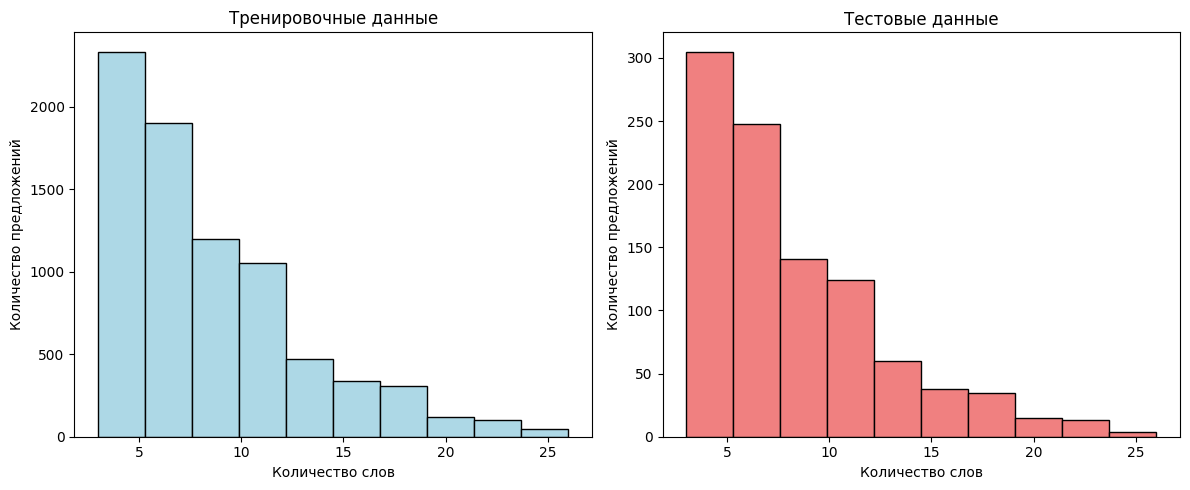

In [ ]:
# Подсчет слов в предложениях для двух датасетов
words1 = [len(sentence.split()) for sentence in all_train_data['sentence']]
words2 = [len(sentence.split()) for sentence in test_dataset['sentence']]

# Строим два графика рядом
plt.figure(figsize=(12, 5))

# Первый график
plt.subplot(1, 2, 1)
plt.hist(words1, color='lightblue', edgecolor='black')
plt.title('Тренировочные данные')
plt.xlabel('Количество слов')
plt.ylabel('Количество предложений')

# Второй график
plt.subplot(1, 2, 2)
plt.hist(words2, color='lightcoral', edgecolor='black')
plt.title('Тестовые данные')
plt.xlabel('Количество слов')
plt.ylabel('Количество предложений')

plt.tight_layout()
plt.show()

Итого в предложениях обычно не более 25 слов. Значит, для их кодирования вполне подойдут вектора длины 128.

  Преобразуем все датасеты в формат dataset для работы с библиотекой Hugging face

In [ ]:
val_dataset = Dataset.from_pandas(val_dataset)
train_dataset = Dataset.from_pandas(train_dataset)
test_dataset = Dataset.from_pandas(test_dataset)

Загрузим модель и токенизатор для бинарной классификации.

In [ ]:
from transformers import AutoTokenizer, AutoModelForSequenceClassification

tokenizer = AutoTokenizer.from_pretrained("ai-forever/ruBert-base")
model = AutoModelForSequenceClassification.from_pretrained(
    "ai-forever/ruBert-base",
    num_labels=2
)

Some weights of BertForSequenceClassification were not initialized from the model checkpoint at ai-forever/ruBert-base and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


In [ ]:
def tokenize_function(examples):
    return tokenizer(
        examples['sentence'],
        padding=True, #выравнивает длину токенов до длины max_length
        truncation=True, #обрезает текст, если он длиннее max_length
        max_length=128
    )

# Применяем токенизацию
val_data = val_dataset.map(tokenize_function, batched=True)
train_data = train_dataset.map(tokenize_function, batched=True)
test_data = test_dataset.map(tokenize_function, batched=True)

Map:   0%|          | 0/983 [00:00<?, ? examples/s]

Map:   0%|          | 0/6886 [00:00<?, ? examples/s]

Map:   0%|          | 0/983 [00:00<?, ? examples/s]

Импортируем метрики для оценки качества обучения. Целевой будем считать метрику F1. Я решила выбрать ее, потому что обучающие данные несбалансированы: корректных примеров сильно больше, чем некорректных. Из-за этого метрика accuracy может быть обманчиво высокой, а модель будет склонна предсказывать более частотный класс. F1 учитывает одновременно Precision и Recall, поэтому она лучше отражает реальное качество модели при несбалансированных данных.

In [ ]:
import numpy as np
from sklearn.metrics import f1_score, precision_score, recall_score

In [ ]:
def compute_metrics(eval_pred):
    predictions, labels = eval_pred
    predictions = np.argmax(predictions, axis=1)

    f1 = f1_score(labels, predictions, average='binary')  # binary для бинарной классификации
    precision = precision_score(labels, predictions, average='binary')
    recall = recall_score(labels, predictions, average='binary')

    return {
        'f1': f1,
        'precision': precision,
        'recall': recall
    }

Импортируем классы TrainingArgumens и Trainer, чтобы задать параметры обучения модели, и функцию EarlyStoppingCallback, чтобы предотвратить переобучение модели - обучение будет останавливаться, когда целевая метрика (F1) на валидационных данных перестанет улучшаться

In [ ]:
from transformers import TrainingArguments, Trainer, EarlyStoppingCallback

In [ ]:
args = TrainingArguments(
    output_dir="./binary-classification-model", #папка для сохранения обученной модели
    eval_strategy="epoch", #оцениваем модель каждую эпоху
    learning_rate=2e-5, #скорость обучения
    per_device_train_batch_size=32, #размер батча тренировочных данных на гпу (у нас она одна)
    per_device_eval_batch_size=32, #размер батча при валидации
    num_train_epochs=10, #кол-во эпох обучения
    weight_decay=0.01, #параметр L2-регуляризации, чтобы модель не переобучалась
    save_strategy="epoch", #как часто сохранять модель
    load_best_model_at_end=True, #сохраняем лучшую модель по результатам обучения
    metric_for_best_model="f1", #соответственно сохраняем ту версию модели, на которой был наибольший f1-score
    greater_is_better=True, #чем больше метрика (f1) тем лучше
    report_to='none' #логи никуда не отправляем, чтобы не приходилось вводить API ключ перед обучением
)

In [ ]:
trainer = Trainer(
    model=model,
    args=args,
    train_dataset=train_data,
    eval_dataset=val_data,  # валидационная выборка для оценки во время обучения
    compute_metrics=compute_metrics,
    processing_class=tokenizer,
    callbacks=[EarlyStoppingCallback(early_stopping_patience=2)]
    # если целевая метрика (F1) на валидационных данных не улучшалась 2 эпохи, то обучение нужно остановить (модель переобучается)
)

In [ ]:
# noisy_logger cкрывает лишние сообщения Trainer во время обучения
import logging
from transformers.trainer import logger as noisy_logger
noisy_logger.setLevel(logging.WARNING)

Запустим обучение модели.

In [ ]:
trainer.train()

Epoch,Training Loss,Validation Loss,F1,Precision,Recall
1,No log,0.799994,0.861695,0.800000,0.933702
2,No log,0.729276,0.864933,0.799531,0.941989
3,0.222500,0.820922,0.868118,0.809069,0.936464
4,0.222500,0.980664,0.866881,0.811071,0.930939
5,0.101900,1.218664,0.865248,0.811366,0.926796


TrainOutput(global_step=1080, training_loss=0.15558666653103298, metrics={'train_runtime': 731.2486, 'train_samples_per_second': 94.168, 'train_steps_per_second': 2.954, 'total_flos': 796003442444400.0, 'train_loss': 0.15558666653103298, 'epoch': 5.0})

Судя по значению F1, модель достигает пика на эпохе 3, после чего улучшение прекращается. Поэтому после 5 эпохи сработал EarlyStopping и обучение прекратилось.

Сохраним лучшую обученную модель.

In [ ]:
trainer.save_model("my_trained_model")  # сохраняет в папку my_trained_model

# Сохранение токенизатора
tokenizer.save_pretrained("my_trained_model")

('my_trained_model/tokenizer_config.json',
 'my_trained_model/special_tokens_map.json',
 'my_trained_model/vocab.txt',
 'my_trained_model/added_tokens.json',
 'my_trained_model/tokenizer.json')

Протестируем нашу модель на тестовых данных:

In [ ]:
trainer.evaluate(test_data)

{'eval_loss': 0.8206218481063843,
 'eval_f1': 0.8638977635782747,
 'eval_precision': 0.8125,
 'eval_recall': 0.922237380627558,
 'eval_runtime': 2.4533,
 'eval_samples_per_second': 400.689,
 'eval_steps_per_second': 12.636,
 'epoch': 5.0}

Качество не сильно упало, значит, модель обучилась хорошо.

Теперь применим нашу модель к реальным примерам.

In [ ]:
from transformers import pipeline

clf = pipeline("text-classification", model=model, tokenizer=tokenizer)
clf("Я познакомилась с человеком, она рассказывала о котором.")

Device set to use cuda:0


[{'label': 'LABEL_0', 'score': 0.7541176676750183}]

0 - это лейбл "некорректное предложение". Классификация верная.

In [ ]:
clf("Я познакомилась с человеком, о котором она рассказывала.")

[{'label': 'LABEL_1', 'score': 0.9204423427581787}]

Лейбл 1 значит, что пример корректен. Оба примера были классифицированы верно.

## Задание 2. Few-/zero-shot модели ruGPT3

Импортируем модель и токенизатор:

In [ ]:
from transformers import AutoTokenizer, AutoModelForCausalLM

tokenizer = AutoTokenizer.from_pretrained("sberbank-ai/rugpt3large_based_on_gpt2")

model = AutoModelForCausalLM.from_pretrained("sberbank-ai/rugpt3large_based_on_gpt2").to(device)

tokenizer_config.json: 0.00B [00:00, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/574 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/622 [00:00<?, ?B/s]

pytorch_model.bin:   0%|          | 0.00/3.14G [00:00<?, ?B/s]

Для классификации мы будем использовать loss модели. Сам по себе этот показатель не несет содержательной информации. Интересно посмотреть, как на него повлияет изменение количества затравок.

In [ ]:
def calc_loss(phrase: str,
                        tokenizer,
                        model):

    phrase = tokenizer.encode(phrase)
    if len(phrase) == 1:
         phrase.append(tokenizer.eos_token_id)
    phrase = torch.tensor(phrase, dtype=torch.long, device=device)
    phrase = phrase.unsqueeze(0)
    with torch.no_grad():
        loss = model(phrase, labels=phrase)

    loss[0].item()


    return loss[0].item()

def get_loss_num(text):
    loss = calc_loss(phrase=text, model=model, tokenizer=tokenizer)
    return loss

def clean(text):
    text = re.sub(r'\((\d+)\)', '', text)
    return text

In [ ]:
text = 'Я познакомилась с человеком, о котором она рассказывала.'

Ноль примеров:

In [ ]:
correct_loss = get_loss_num('Предложение далее корректное? ' + text + " Ответ: да.")
correct_loss

`loss_type=None` was set in the config but it is unrecognized. Using the default loss: `ForCausalLMLoss`.


4.318833827972412

Один пример

In [ ]:
one_shot = ['Предложение далее корректное? ' + 'Я зашла в магазин, который недавно открылся.' + " Ответ: да."]
correct_loss = get_loss_num('\n'.join(one_shot) +'\nПредложение далее корректное? ' + text + " Ответ: да.")
correct_loss

3.022738218307495

Два примера

In [ ]:
two_shots = ['Предложение далее корректное? ' + 'Я поступила в институт, который рекомендовал мой брат.' + " Ответ: да.",
             'Предложение далее корректное? ' + 'В институт, рекомендовал мой брат, который я поступила.' + " Ответ: нет."]
correct_loss = get_loss_num('\n'.join(two_shots) +'\nПредложение далее корректное? ' + text + " Ответ: да.")
correct_loss

2.699875831604004

Четыре примера

In [ ]:
four_shots = ['Предложение далее корректное? ' + 'Я забрала домой котенка, который жил на улице.' + " Ответ: да.",
             'Предложение далее корректное? ' + 'Котенка, жил на улице, которого я забрала домой.' + " Ответ: нет.",
             'Предложение далее корректное? ' + 'Я купила платье, о котором мне рассказывала подруга.' + " Ответ: да.",
             'Предложение далее корректное? ' + 'Подруга платье о котором рассказывала, я купила.' + " Ответ: нет."]
correct_loss = get_loss_num('\n'.join(four_shots) +'\nПредложение далее корректное? ' + text + " Ответ: да.")
correct_loss

2.0117909908294678

 Можно сделать вывод, что чем больше затравок, тем меньше значение ошибки модели, а значит предсказывает она лучше.